# Filtering pathogen-specific bioassays

## 00. Setup

In [36]:
from pathlib import Path
import shutil
import os
import json
from bs4 import BeautifulSoup
import gzip
from tqdm import tqdm
import zipfile
import pandas as pd
import ast
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Project paths
NOTEBOOK_DIR = Path().resolve()
DATA_RAW = NOTEBOOK_DIR.parent / "data" / "raw"
DATA_PROCESSED = NOTEBOOK_DIR.parent / "data" / "processed"
PUBCHEM_DIR = DATA_RAW / "pubchem_bioassays"
DESC_DIR = PUBCHEM_DIR / "Description"
DATA_DIR = PUBCHEM_DIR / "Data"

## 01. Prepare folders for KEPT assays

In [3]:
KEEP_DIR = DATA_RAW / "filtered_assays"
KEEP_DESC = KEEP_DIR / "Description"
KEEP_DATA = KEEP_DIR / "Data"

KEEP_DESC.mkdir(parents=True, exist_ok=True)
KEEP_DATA.mkdir(parents=True, exist_ok=True)

## 02. Load pathogen TaxIDs

In [4]:
# Load dictionary mapping pathogen → list of TaxIDs
dict_taxonomy = json.load(open(DATA_PROCESSED / "dict_taxonomy.json"))

In [5]:
# Turn dict_taxonomy into ONE set of all taxids we want
target_taxid_set = set()
for lst in dict_taxonomy.values():
    target_taxid_set.update(map(str, lst))

len(target_taxid_set), list(target_taxid_set)[:10]

(2288,
 ['2663329',
  '1281241',
  '1094989',
  '1247414',
  '2267891',
  '1402485',
  '1002648199',
  '1169339',
  '1401639',
  '1003522185'])

## 03. Function to extract TaxIDs from a .descr.xml

PubChem XML stores protein/gene/strain targets like:

In [ ]:
<PC-AssayDescription_target>
    <PC-AssayTarget_tax-id>1773</PC-AssayTarget_tax-id>
</PC-AssayDescription_target>

An assay may have 0, 1, or many targets, so we'll make `targets` a list of all these nodes.

In [6]:
def extract_taxids_from_descr(xml_path):
    """
    Extract all taxonomy IDs from a PubChem .descr.xml or .descr.xml.gz file.
    Returns a set of TaxID strings.
    """

    # ----- Load XML (compressed or plain) -----
    if str(xml_path).endswith(".gz"):
        with gzip.open(xml_path, "rb") as f:
            xml_content = f.read()
    else:
        with open(xml_path, "rb") as f:
            xml_content = f.read()

    soup = BeautifulSoup(xml_content, "lxml-xml")

    taxids = set()  # A set automatically removes duplicates: {"1773", "1773", "1773"} → {"1773"}

    # ----- (1) Extract taxids from target block -----
    for t in soup.find_all("PC-AssayTarget_tax-id"):
        if t.text.isdigit():
            taxids.add(t.text)

    # ----- (2) Extract taxids from XRef block -----
    for x in soup.find_all("PC-XRefData_taxonomy"):
        if x.text.isdigit():
            taxids.add(x.text)

    # ----- (3) Rare: result-type taxonomy -------
    for r in soup.find_all("PC-AssayResultType_tax-id"):
        if r.text.isdigit():
            taxids.add(r.text)

    return taxids

## 04. Loop through ALL Description files, filter and keep/delete uncompressed XML

In [16]:
# Find all ZIP files in Description folder
zip_files = list(DESC_DIR.glob("*.zip"))
len(zip_files)

1792

In [33]:
# Trying with one Description .zip folder

# Storage for collected pairs
records = []     # will store dicts: {"AID": X, "TaxIDs": [...]} 

# Choose ONE ZIP file for testing
test_zip = DESC_DIR / "1368001_1369000.zip" # We chose this one since we know it contains AID 1368269 for Acinetobacter baumannii
zip_chunk = test_zip.stem
print("Testing ZIP:", test_zip)

# Temporary extraction folder
temp_extract = DESC_DIR / f"{test_zip.stem}_tmp"
temp_extract.mkdir(exist_ok=True)
print("Extracting into:", temp_extract)

# 1) Extract ZIP contents temporarily
with zipfile.ZipFile(test_zip, "r") as zf:
    zf.extractall(temp_extract)

# 2) Collect XML and XML.GZ files
xml_files = list(temp_extract.rglob("*.xml.gz")) + list(temp_extract.rglob("*.xml"))
print("Found XML files:", len(xml_files))

matched_for_test = set()

# 3) Process each XML file
for xml_path in tqdm(xml_files, desc="Scanning extracted XMLs"):
    taxids = extract_taxids_from_descr(xml_path)

    # If assay matches ANY pathogen taxid → keep it
    if taxids & target_taxid_set:
        aid = int(Path(xml_path).stem.split(".")[0])
        matched_for_test.add(aid)

        # Save record for later DATA extraction
        records.append({
            "AID": aid,
            "TaxIDs_detected": sorted(list(taxids)),
            "ZipFolder": zip_chunk
        })

        # Save uncompressed XML into KEEP_DESC
        dest_path = KEEP_DESC / f"{aid}.xml"

        if str(xml_path).endswith(".gz"):
            with gzip.open(xml_path, "rb") as f_in:
                with open(dest_path, "wb") as f_out:
                    f_out.write(f_in.read())
        else:
            shutil.copy2(xml_path, dest_path)

# Remove temporary folder
shutil.rmtree(temp_extract)
print("✓ Removed temporary extraction folder")

# Show results
print("\n✔ Test complete!")
print("Matched AIDs:", matched_for_test)
print("Number matched:", len(matched_for_test))

# Convert to DataFrame (for later use)
df_test_results = pd.DataFrame(records)
df_test_results

Testing ZIP: /Users/maria/Documents/Ersilia/PubChem/pubchem-antimicrobial-tasks/data/raw/pubchem_bioassays/Description/1368001_1369000.zip
Extracting into: /Users/maria/Documents/Ersilia/PubChem/pubchem-antimicrobial-tasks/data/raw/pubchem_bioassays/Description/1368001_1369000_tmp
Found XML files: 1000


Scanning extracted XMLs: 100%|██████████| 1000/1000 [00:44<00:00, 22.68it/s]


✓ Removed temporary extraction folder

✔ Test complete!
Matched AIDs: {1368991, 1368992, 1368993, 1368994, 1368355, 1368275, 1368746, 1368747, 1368748, 1368006, 1368268, 1368269, 1368271, 1368272, 1368273, 1368274, 1368411, 1368276, 1368277, 1368278, 1368279, 1368280, 1368281, 1368282, 1368283, 1368284, 1368412, 1368413, 1368415, 1368288, 1368289, 1368290, 1368291, 1368414, 1368285, 1368287, 1368286, 1368416, 1368417, 1368299, 1368174, 1368176, 1368702}
Number matched: 43


,AID,TaxIDs_detected,ZipFolder
0,1368355,[5833],1368001_1369000
1,1368288,[470],1368001_1369000
2,1368277,[1280],1368001_1369000
3,1368412,[1773],1368001_1369000
4,1368991,[208964],1368001_1369000
5,1368415,[1773],1368001_1369000
6,1368276,[470],1368001_1369000
7,1368289,[470],1368001_1369000
8,1368271,[1280],1368001_1369000
9,1368414,[1773],1368001_1369000


In [ ]:
# ETA: 1432min 

# ---------------------------------------
# Resume support: track which ZIP chunks are done
# ---------------------------------------
zip_log = DATA_PROCESSED / "processed_zip_chunks.txt"

if zip_log.exists():
    processed_chunks = set(zip_log.read_text().splitlines())
else:
    processed_chunks = set()

# ---------------------------------------
# Loop to check ALL Description folders
# ---------------------------------------

all_records = []      # list of dicts: {"AID", "TaxIDs_detected", "ZipFolder"}
already_saved = set() # to avoid writing same XML twice
total_matched_global = 0

for zip_file in tqdm(zip_files, desc="Processing ZIP chunks"):
    
    zip_chunk = zip_file.stem

    # --------------- RESUME SUPPORT ---------------
    if zip_chunk in processed_chunks:
        print(f"⏩ Skipping {zip_chunk} (already processed)")
        continue
    # ----------------------------------------------

    print(f"\n=== Processing ZIP: {zip_chunk} ===")

    # Temporary extraction folder
    temp_extract = DESC_DIR / f"{zip_chunk}_tmp"
    temp_extract.mkdir(exist_ok=True)

    # 1) Extract contents
    with zipfile.ZipFile(zip_file, "r") as zf:
        zf.extractall(temp_extract)

    # 2) Locate XML files
    xml_files = list(temp_extract.rglob("*.xml.gz")) + list(temp_extract.rglob("*.xml"))
    print(f"Found XML files: {len(xml_files)}")

    matched_for_zip = []

    # 3) Scan XML files
    for xml_path in tqdm(xml_files, desc=f"Scanning XMLs in {zip_chunk}", leave=False):
        taxids = extract_taxids_from_descr(xml_path)

        if taxids & target_taxid_set:
            aid = int(Path(xml_path).stem.split(".")[0])

            matched_for_zip.append(aid)
            total_matched_global += 1

            all_records.append({
                "AID": aid,
                "TaxIDs_detected": sorted(list(taxids)),
                "ZipFolder": zip_chunk
            })

            # Save uncompressed XML only once
            if aid not in already_saved:
                dest_path = KEEP_DESC / f"{aid}.xml"

                if str(xml_path).endswith(".gz"):
                    with gzip.open(xml_path, "rb") as f_in:
                        with open(dest_path, "wb") as f_out:
                            f_out.write(f_in.read())
                else:
                    shutil.copy2(xml_path, dest_path)

                already_saved.add(aid)

    # 4) Clean up
    shutil.rmtree(temp_extract)
    print(f"✓ Finished ZIP {zip_chunk}, removed temp folder")

    # --------------- MARK ZIP AS DONE ---------------
    with open(zip_log, "a") as f:

        f.write(zip_chunk + "\n")
    processed_chunks.add(zip_chunk)
    # ------------------------------------------------

# ---------------------------------------
# Convert results to DataFrame
# ---------------------------------------
df_results = pd.DataFrame(all_records)
df_results.to_csv(DATA_PROCESSED / "filtered_assays_description_results.csv", index=False)

print("\n\n=====================================")
print("✔ ALL ZIP FILES PROCESSED SUCCESSFULLY")
print("✔ Filtered XML files saved in:", KEEP_DESC)
print("✔ Full results saved as: filtered_assays_description_results.csv")
print("Total matched AIDs:", df_results["AID"].nunique())
print("=====================================")

Processing ZIP chunks:   0%|          | 0/1792 [00:00<?, ?it/s]


=== Processing ZIP: 0000001_0001000 ===
Found XML files: 776


Processing ZIP chunks:   0%|          | 1/1792 [01:06<32:58:26, 66.28s/it]

✓ Finished ZIP 0000001_0001000, removed temp folder

=== Processing ZIP: 0001001_0002000 ===
Found XML files: 991


Processing ZIP chunks:   0%|          | 2/1792 [02:55<45:33:50, 91.64s/it]

...

✓ Finished ZIP 2059001_2060000, removed temp folder

=== Processing ZIP: 2060001_2061000 ===
Found XML files: 868


Processing ZIP chunks: 100%|█████████▉| 1791/1792 [23:51:20<00:45, 45.78s/it]

✓ Finished ZIP 2060001_2061000, removed temp folder

=== Processing ZIP: 2061001_2062000 ===
Found XML files: 597


Processing ZIP chunks: 100%|██████████| 1792/1792 [23:52:09<00:00, 47.95s/it]


✓ Finished ZIP 2061001_2062000, removed temp folder


✔ ALL ZIP FILES PROCESSED SUCCESSFULLY
✔ Filtered XML files saved in: /Users/maria/Documents/Ersilia/PubChem/pubchem-antimicrobial-tasks/data/raw/filtered_assays/Description
✔ Full results saved as: filtered_assays_description_results.csv
Total matched AIDs: 129453


In [7]:
# Load filtered Description results
df_descr = pd.read_csv(DATA_PROCESSED / "filtered_assays_description_results.csv")
df_descr.head()

,AID,TaxIDs_detected,ZipFolder
0,838,['1773'],0000001_0001000
1,709,['373153'],0000001_0001000
2,708,['373153'],0000001_0001000
3,557,['373153'],0000001_0001000
4,375,['1773'],0000001_0001000


TaxID_detected is saved as strings!

In [8]:
#  Convert stringified lists back into real Python lists
df_descr["TaxIDs_detected"] = df_descr["TaxIDs_detected"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
df_descr.head()

,AID,TaxIDs_detected,ZipFolder
0,838,[1773],0000001_0001000
1,709,[373153],0000001_0001000
2,708,[373153],0000001_0001000
3,557,[373153],0000001_0001000
4,375,[1773],0000001_0001000


In [9]:
# Mapping TaxID → Pathogen
taxid_to_pathogen = {}
for pathogen, taxids in dict_taxonomy.items():
    for t in taxids:
        taxid_to_pathogen[str(t)] = pathogen

# Assign pathogen to each matched assay
df_descr["Pathogen"] = df_descr["TaxIDs_detected"].apply(
    lambda lst: taxid_to_pathogen.get(str(lst[0]), None)
)

# Count
summary_descr = (
    df_descr.groupby("Pathogen")["AID"]
    .nunique()
    .reset_index(name="Downloaded_PubChem_AIDs")
)
summary_descr

,Pathogen,Downloaded_PubChem_AIDs
0,Acinetobacter baumannii,3576
1,Campylobacter,341
2,Candida albicans,13191
3,Enterobacter,2195
4,Enterococcus faecium,1995
5,Escherichia coli,24568
6,Helicobacter pylori,913
7,Klebsiella pneumoniae,5800
8,Mycobacterium tuberculosis,12698
9,Neisseria gonorrhoeae,500


In [11]:
summary_by_pathogen = pd.read_csv(DATA_PROCESSED / "summary_by_pathogen.csv")
summary_by_pathogen

,Pathogen,PubChem_Web_AIDs,Taxonomy_AIDs,PUGREST_AIDs,Aid2Taxid_AIDs,Downloaded_PubChem_AIDs_x,Downloaded_PubChem_AIDs_y,Downloaded_PubChem_AIDs
0,Escherichia coli,63263,3415,17850,20163,24568,24568,3576
1,Staphylococcus aureus,59672,1896,30774,26830,33766,33766,341
2,Pseudomonas aeruginosa,26093,2414,12526,11161,14528,14528,13191
3,Mycobacterium tuberculosis,25323,3808,10290,10040,12698,12698,2195
4,Plasmodium falciparum,24519,1967,8229,8150,10149,10149,1995
5,Candida albicans,23814,3114,11878,10449,13191,13191,24568
6,Acinetobacter baumannii,15778,1442,3286,2422,3576,3576,913
7,Klebsiella pneumoniae,11883,1535,5360,4477,5800,5800,5800
8,Streptococcus pneumoniae,9474,1584,4012,4193,4362,4362,12698
9,Enterobacter,4023,2257,1922,1863,2195,2195,500


In [10]:
summary_by_pathogen = pd.read_csv(DATA_PROCESSED / "summary_by_pathogen.csv")

summary_by_pathogen = summary_by_pathogen.merge(
    summary_descr, on="Pathogen", how="left"
)
summary_by_pathogen["Downloaded_PubChem_AIDs"] = summary_by_pathogen["Downloaded_PubChem_AIDs"].fillna(0)

first_column = ['Pathogen','PubChem_Web_AIDs']
other_columns = [c for c in summary_by_pathogen.columns if c not in first_column]
summary_by_pathogen = summary_by_pathogen[first_column + other_columns]

filepath = DATA_PROCESSED / "summary_by_pathogen.csv"
summary_by_pathogen.to_csv(filepath, index=False)

summary_by_pathogen

MergeError: Passing 'suffixes' which cause duplicate columns {'Downloaded_PubChem_AIDs_x'} is not allowed.

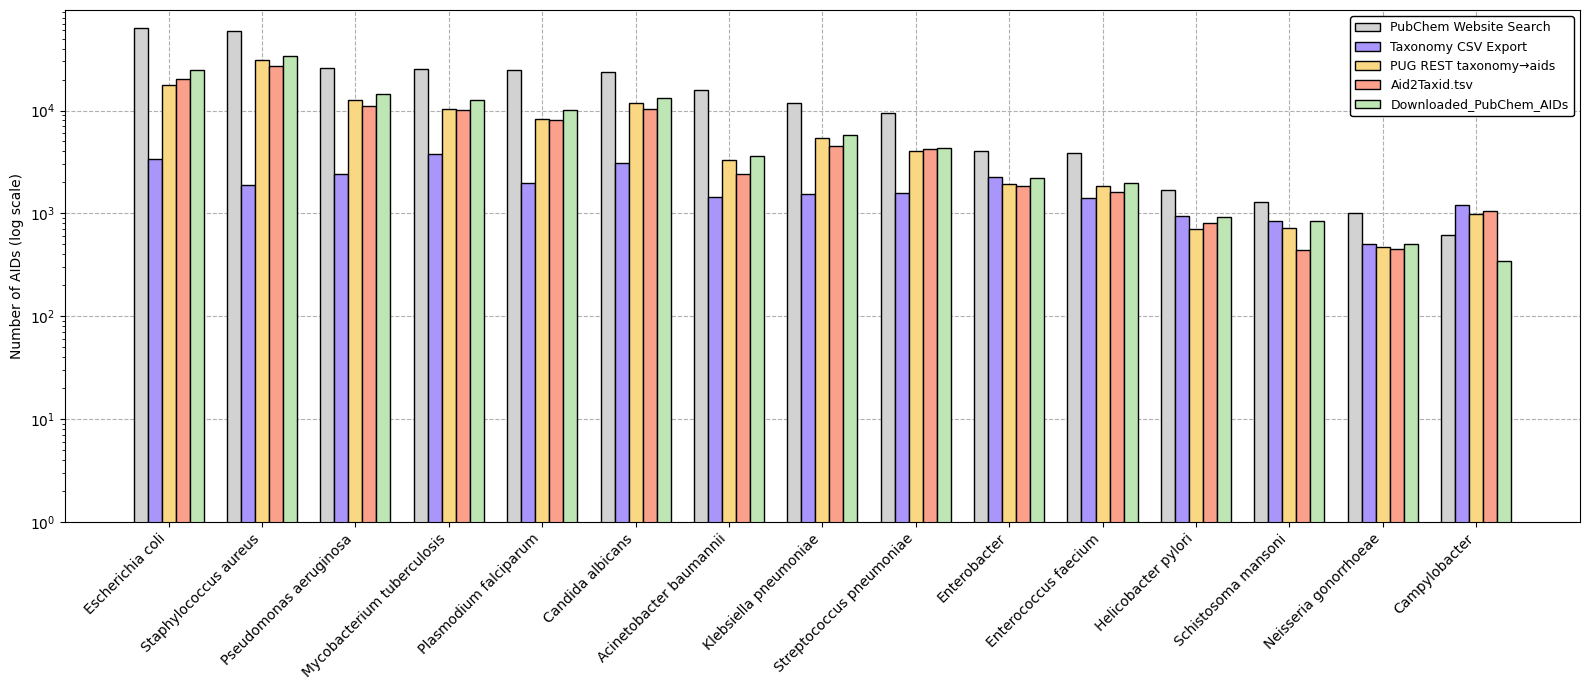

In [20]:
# Extract arrays
labels           = summary_by_pathogen["Pathogen"].values
PubChem_Web_AIDs = summary_by_pathogen["PubChem_Web_AIDs"].values
Taxonomy_AIDs    = summary_by_pathogen["Taxonomy_AIDs"].values
PUGREST_AIDs     = summary_by_pathogen["PUGREST_AIDs"].values
Aid2Taxid_AIDs   = summary_by_pathogen["Aid2Taxid_AIDs"].values
Downloaded_PubChem_AIDs = summary_by_pathogen["Downloaded_PubChem_AIDs"].values   # NEW

N = len(labels)
x = np.arange(N)

bar_width = 0.15   # fit 5 bars

plt.figure(figsize=(16, 7))

# 1. PubChem Web UI
plt.bar(x - 2*bar_width, PubChem_Web_AIDs, width=bar_width,
        color="#D2D2D2", ec="black", zorder=2, label="PubChem Website Search")

# 2. Taxonomy CSV
plt.bar(x - bar_width, Taxonomy_AIDs, width=bar_width,
        color="#AA96FA", ec="black", zorder=2, label="Taxonomy CSV Export")

# 3. PUG REST
plt.bar(x, PUGREST_AIDs, width=bar_width,
        color="#FAD782", ec="black", zorder=2, label="PUG REST taxonomy→aids")

# 4. Aid2Taxid.tsv
plt.bar(x + bar_width, Aid2Taxid_AIDs, width=bar_width,
        color="#FAA08B", ec="black", zorder=2, label="Aid2Taxid.tsv")

# 5. Downloaded_PubChem_AIDs
plt.bar(x + 2*bar_width, Downloaded_PubChem_AIDs, width=bar_width,
        color="#BEE6B4", ec="black", zorder=2, label="Downloaded_PubChem_AIDs")

plt.yscale("log")
plt.ylim([1, PubChem_Web_AIDs.max() * 1.5])

plt.xticks(x, labels, rotation=45, ha="right")
plt.ylabel("Number of AIDs (log scale)")

plt.grid(linestyle="--", zorder=1)
plt.legend(loc="upper right", framealpha=1, edgecolor="k", prop={"size": 9})

plt.tight_layout()
plt.show()

## 05. Adding `assay organism`

PubChem also contains information about `assay organism` under `PC-AnnotatedXRef_comment`, which in many cases is where we can find pathogen information not described in `taxid`or `taxonomy`.

Also, we want to collect the `ChEMBL id` of each assay, if present.

In [ ]:
def extract_info_from_descr(xml_path):
    """
    Extract:
    - TaxIDs (target, xref, result-type)
    - Assay organism (PC-AnnotatedXRef_comment)
    - ChEMBL ID (Object-id_str inside PC-DBTracking)
    """

    # ---- Load XML (compressed or plain) ----
    if str(xml_path).endswith(".gz"):
        with gzip.open(xml_path, "rb") as f:
            xml_content = f.read()
    else:
        with open(xml_path, "rb") as f:
            xml_content = f.read()

    soup = BeautifulSoup(xml_content, "lxml-xml")

    # ------------------------------------------------
    # 1. Collect TaxIDs (FULL v1 logic restored)
    # ------------------------------------------------
    taxids = set()

    # (A) PC-AssayTarget_tax-id
    for node in soup.find_all("PC-AssayTarget_tax-id"):
        txt = node.text.strip()
        if txt.isdigit():
            taxids.add(txt)

    # (B) PC-XRefData_taxonomy
    for node in soup.find_all("PC-XRefData_taxonomy"):
        txt = node.text.strip()
        if txt.isdigit():
            taxids.add(txt)

    # (C) PC-AssayResultType_tax-id
    for node in soup.find_all("PC-AssayResultType_tax-id"):
        txt = node.text.strip()
        if txt.isdigit():
            taxids.add(txt)

    # ------------------------------------------------
    # 2. Collect Assay organism
    # ------------------------------------------------
    assay_organisms = []

    for node in soup.find_all("PC-AnnotatedXRef_comment"):
        txt = node.text.strip()
        if txt:
            assay_organisms.append(txt)

    # keep meaningful organism names
    assay_organisms = [x for x in assay_organisms if len(x) > 3]

    # ------------------------------------------------
    # 3. Extract ChEMBL ID
    # ------------------------------------------------
    chembl_id = None

    for db in soup.find_all("PC-DBTracking"):
        name = db.find("PC-DBTracking_name")
        if name and name.text.strip() == "ChEMBL":
            obj = db.find("Object-id_str")
            if obj:
                chembl_id = obj.text.strip()
                break

    return {
        "TaxIDs": sorted(list(taxids)),
        "AssayOrganism": assay_organisms,
        "ChEMBL": chembl_id
    }

In [52]:
# Reverse mapping TaxID → pathogen, to 
taxid_to_pathogen = {}
for pathogen, taxids in dict_taxonomy.items():
    for t in taxids:
        taxid_to_pathogen[str(t)] = pathogen

# Pathogens of interest
pathogens = [
    "Acinetobacter baumannii", "Candida albicans", "Campylobacter",
    "Escherichia coli", "Enterococcus faecium", "Enterobacter",
    "Helicobacter pylori", "Klebsiella pneumoniae",
    "Mycobacterium tuberculosis", "Neisseria gonorrhoeae",
    "Pseudomonas aeruginosa", "Plasmodium falciparum",
    "Staphylococcus aureus", "Schistosoma mansoni",
    "Streptococcus pneumoniae"
]

In [ ]:
#  Decide if ONE assay belongs to ANY pathogen

def detect_matching_pathogens(info):
    matched = set()

    # --- A) Match by TaxID ---
    for tid in info["TaxIDs"]:
        if tid in taxid_to_pathogen:
            matched.add(taxid_to_pathogen[tid])

    # --- B) Match by organism name ---
    for org in info["AssayOrganism"]:
        org_low = org.lower()
        for pathogen in pathogens:
            if pathogen.lower() in org_low:
                matched.add(pathogen)

    return sorted(list(matched))


In [57]:
# Minimal loop: test folder

# Choose test folder
test_zip = DESC_DIR / "1368001_1369000.zip"
zip_chunk = test_zip.stem

print("Testing:", zip_chunk)

# Extract to temp folder
temp = DESC_DIR / f"{zip_chunk}_tmp"
temp.mkdir(exist_ok=True)

with zipfile.ZipFile(test_zip, "r") as zf:
    zf.extractall(temp)

# Find XML files
xml_files = list(temp.rglob("*.xml")) + list(temp.rglob("*.xml.gz"))
print("Found:", len(xml_files))

records = []

for xml_path in tqdm(xml_files, desc="Scanning"):
    
    info = extract_info_from_descr(xml_path)
    pathogens_hit = detect_matching_pathogens(info)

    if pathogens_hit:
        aid = int(Path(xml_path).stem.split(".")[0])

        # Save XML (always overwrite)
        out_path = KEEP_DESC / f"{aid}.xml"
        if out_path.exists():
            out_path.unlink()

        if xml_path.suffix == ".gz":
            with gzip.open(xml_path, "rb") as f_in:
                with open(out_path, "wb") as f_out:
                    f_out.write(f_in.read())
        else:
            shutil.copy2(xml_path, out_path)

        # Append row
        records.append({
            "AID": aid,
            "Pathogen": ", ".join(pathogens_hit),
            "ChEMBLid": info["ChEMBL"],
            "ZipFolder": zip_chunk
        })

# Clean up
shutil.rmtree(temp)

df_test_results = pd.DataFrame(records)
print("Number matched:", len(df_test_results))
df_test_results

Testing: 1368001_1369000
Found: 1000


Scanning: 100%|██████████| 1000/1000 [00:36<00:00, 27.32it/s]


Number matched: 43


,AID,Pathogen,ChEMBLid,ZipFolder
0,1368355,Plasmodium falciparum,CHEMBL4182253,1368001_1369000
1,1368288,Acinetobacter baumannii,CHEMBL4182186,1368001_1369000
2,1368277,Staphylococcus aureus,CHEMBL4182175,1368001_1369000
3,1368412,Mycobacterium tuberculosis,CHEMBL4182310,1368001_1369000
4,1368991,Pseudomonas aeruginosa,CHEMBL4182889,1368001_1369000
5,1368415,Mycobacterium tuberculosis,CHEMBL4182313,1368001_1369000
6,1368276,Acinetobacter baumannii,CHEMBL4182174,1368001_1369000
7,1368289,Acinetobacter baumannii,CHEMBL4182187,1368001_1369000
8,1368271,Staphylococcus aureus,CHEMBL4182169,1368001_1369000
9,1368414,Mycobacterium tuberculosis,CHEMBL4182312,1368001_1369000


## 06. Parallellizing the process (Parallel within ZIP)

This has been done using `scripts/run_parallel_extract.py`, and the following files have been produced:

- data/raw/filtered_assays/Description/AID.xml
- data/processed/parallel_speed_log.txt
- data/processed/filtered_description_with_organisms.csv 
- data/processed/processed_zip_chunks_with_organisms.txt

Let's cpunt and check outputs per pathogen:

In [4]:
from pathlib import Path
import pandas as pd
from bs4 import BeautifulSoup
import gzip
from tqdm.auto import tqdm

# Project root (this is the one you're using in the script)
PROJECT_ROOT = Path("/Users/maria/Documents/Ersilia/PubChem/pubchem-antimicrobial-tasks")

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

KEEP_DESC_V2 = DATA_RAW / "filtered_assays_v2" / "Description"

print("XML files in v2 folder:", len(list(KEEP_DESC_V2.glob("*.xml"))))

/opt/anaconda3/envs/pamt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


XML files in v2 folder: 129927


In [5]:
# Load taxonomy table
tax_df = pd.read_csv(DATA_PROCESSED / "taxonomy_table.csv")

# Build dict: pathogen -> list of TaxIDs as strings
dict_taxonomy = (
    tax_df.groupby("Pathogen")["Taxonomy_ID"]
          .apply(lambda s: list(map(str, s)))
          .to_dict()
)

# Reverse map: TaxID -> pathogen
taxid_to_pathogen = {
    tid: pathogen
    for pathogen, tids in dict_taxonomy.items()
    for tid in tids
}

pathogens = list(dict_taxonomy.keys())
len(taxid_to_pathogen), pathogens[:5]

(2288,
 ['Acinetobacter baumannii',
  'Campylobacter',
  'Candida albicans',
  'Enterobacter',
  'Enterococcus faecium'])

Reuse the extraction + matching logic (but now on the FILTERED XMLs)

Define the same functions you used in the script, but now to operate on the XMLs in filtered_assays_v2/Description:

In [11]:
def extract_info_from_descr(xml_path):
    """
    Extract:
    - TaxIDs from 3 different XML fields (returned separately)
    - Assay organism strings
    - ChEMBL ID
    """

    # ---- Load XML ----
    if str(xml_path).endswith(".gz"):
        with gzip.open(xml_path, "rb") as f:
            xml_content = f.read()
    else:
        with open(xml_path, "rb") as f:
            xml_content = f.read()

    soup = BeautifulSoup(xml_content, "lxml-xml")

    # -----------------------------
    # TAXID SOURCES
    # -----------------------------

    # (A) PC-AssayTarget_tax-id
    taxid_assay_target = []
    for node in soup.find_all("PC-AssayTarget_tax-id"):
        txt = node.text.strip()
        if txt.isdigit():
            taxid_assay_target.append(txt)

    # (B) PC-XRefData_taxonomy
    taxid_xref = []
    for node in soup.find_all("PC-XRefData_taxonomy"):
        txt = node.text.strip()
        if txt.isdigit():
            taxid_xref.append(txt)

    # (C) PC-AssayResultType_tax-id
    taxid_result_type = []
    for node in soup.find_all("PC-AssayResultType_tax-id"):
        txt = node.text.strip()
        if txt.isdigit():
            taxid_result_type.append(txt)

    # Combined unique TaxIDs (union)
    taxids_all = sorted(set(
        taxid_assay_target + taxid_xref + taxid_result_type
    ))

    # -----------------------------
    # Assay organism strings
    # -----------------------------
    assay_organisms = []
    for node in soup.find_all("PC-AnnotatedXRef_comment"):
        txt = node.text.strip()
        if txt:
            assay_organisms.append(txt)
    assay_organisms = [x for x in assay_organisms if len(x) > 3]

    # -----------------------------
    # ChEMBL
    # -----------------------------
    chembl_id = None
    for db in soup.find_all("PC-DBTracking"):
        name = db.find("PC-DBTracking_name")
        if name and name.text.strip() == "ChEMBL":
            obj = db.find("Object-id_str")
            if obj:
                chembl_id = obj.text.strip()
                break

    return {
        "TaxID_AssayTarget": taxid_assay_target,
        "TaxID_XRef": taxid_xref,
        "TaxID_ResultType": taxid_result_type,
        "TaxIDs_All": taxids_all,
        "AssayOrganism": assay_organisms,
        "ChEMBL": chembl_id,
    }

def detect_matching_pathogens(info, taxid_to_pathogen, pathogens):
    matched = set()

    # Match by ANY of the 3 taxid sources
    for tid in info["TaxIDs_All"]:
        if tid in taxid_to_pathogen:
            matched.add(taxid_to_pathogen[tid])

    # Match by organism substring
    for org in info["AssayOrganism"]:
        org_low = org.lower()
        for pathogen in pathogens:
            if pathogen.lower() in org_low:
                matched.add(pathogen)

    return sorted(matched)

In [7]:
# Rebuild the V2 metadata CSV from the XML folder
records = []
xml_files = sorted(KEEP_DESC_V2.glob("*.xml"))
len(xml_files)

129927

In [12]:
records = []

for xml_path in tqdm(xml_files, desc="Rebuilding V2 metadata"):
    try:
        info = extract_info_from_descr(xml_path)
        pathogens_hit = detect_matching_pathogens(info, taxid_to_pathogen, pathogens)

        # If an XML slipped through the filter before, we keep it but annotate the miss
        if not pathogens_hit:
            continue

        aid = int(xml_path.stem)

        records.append({
            "AID": aid,
            "Pathogen": ", ".join(pathogens_hit),
            "ChEMBLid": info["ChEMBL"],
            "TaxID_AssayTarget": info["TaxID_AssayTarget"],
            "TaxID_XRef": info["TaxID_XRef"],
            "TaxID_ResultType": info["TaxID_ResultType"],
            "TaxIDs_All": info["TaxIDs_All"], 
            "AssayOrganism": info["AssayOrganism"],
        })

    except Exception:
        continue

Rebuilding V2 metadata: 100%|██████████| 129927/129927 [1:57:19<00:00, 18.46it/s]  


In [15]:
df_v2 = pd.DataFrame(records).drop_duplicates(subset=["AID"])
df_v2.to_csv(DATA_PROCESSED / "filtered_description_with_organisms_v2_REBUILT.csv", index=False)

print("Rebuilt V2 CSV rows:", len(df_v2))
print("Unique AIDs in rebuilt V2:", df_v2["AID"].nunique())

Rebuilt V2 CSV rows: 129927
Unique AIDs in rebuilt V2: 129927


In [16]:
# Compute the REAL per-pathogen final V2 counts

# Use the rebuilt V2 metadata
df_v2 = df_v2.copy()

# Split Pathogen into a list
df_v2["Pathogen_list"] = df_v2["Pathogen"].str.split(", ")

# Explode into one row per (AID, Pathogen)
df_exp = df_v2.explode("Pathogen_list", ignore_index=True)
df_exp = df_exp.rename(columns={"Pathogen_list": "Pathogen_single"})

# Drop empties
df_exp = df_exp.dropna(subset=["Pathogen_single"])
df_exp = df_exp[df_exp["Pathogen_single"].str.len() > 0]

# REAL final V2 counts
summary_v2 = (
    df_exp.groupby("Pathogen_single")["AID"]
    .nunique()
    .reset_index()
    .rename(columns={"Pathogen_single": "Pathogen",
                     "AID": "XML_Taxid_Organism_AIDs_V2"})
)

summary_v2 = summary_v2.sort_values("Pathogen")
summary_v2.to_csv(DATA_PROCESSED / "summary_pathogen_v2_REBUILT.csv", index=False)
summary_v2

,Pathogen,XML_Taxid_Organism_AIDs_V2
0,Acinetobacter baumannii,3582
1,Campylobacter,342
2,Candida albicans,13204
3,Enterobacter,2512
4,Enterococcus faecium,1995
5,Escherichia coli,24617
6,Helicobacter pylori,934
7,Klebsiella pneumoniae,5800
8,Mycobacterium tuberculosis,12746
9,Neisseria gonorrhoeae,500


In [17]:
def aid_matched_by_taxid(row):
    """Return True if this AID matched pathogen via ANY taxid source."""
    taxids = set(row["TaxIDs_All"])
    return len(taxids & set(taxid_to_pathogen.keys())) > 0


def aid_matched_by_organism(row, pathogen):
    """Return True if organism string contains the pathogen name."""
    orgs = row["AssayOrganism"]
    pathogen_low = pathogen.lower()
    return any(pathogen_low in o.lower() for o in orgs)

In [18]:
df_v2["Pathogen_list"] = df_v2["Pathogen"].str.split(", ")
df_expanded = df_v2.explode("Pathogen_list", ignore_index=True)
df_expanded = df_expanded.rename(columns={"Pathogen_list": "Pathogen_single"})
df_expanded = df_expanded.dropna(subset=["Pathogen_single"])

In [24]:
# 1) TaxID match (any of the 3 sources)
df_expanded["Match_TaxID"] = df_expanded["TaxIDs_All"].apply(
    lambda lst: any(t in taxid_to_pathogen for t in lst)
)

df_expanded["Match_Organism"] = df_expanded.apply(
    lambda row: any(row["Pathogen_single"].lower() in o.lower()
                    for o in row["AssayOrganism"]),
    axis=1
)

df_expanded["Only_TaxID"] = (
    df_expanded["Match_TaxID"] &
    ~df_expanded["Match_Organism"]
)

df_expanded["Only_Organism"] = (
    df_expanded["Match_Organism"] &
    ~df_expanded["Match_TaxID"]
)

In [29]:
summary_sources = (
    df_expanded
    .groupby("Pathogen_single")
    .agg(
        AIDs_total=("AID", "nunique"),
        AIDs_taxid=("Match_TaxID", lambda x: df_expanded.loc[x.index[x], "AID"].nunique()),
        AIDs_organism=("Match_Organism", lambda x: df_expanded.loc[x.index[x], "AID"].nunique()),
        AIDs_both=("AID", 
                   lambda aids: df_expanded.loc[
                       aids.index[
                           df_expanded.loc[aids.index, "Match_TaxID"] &
                           df_expanded.loc[aids.index, "Match_Organism"]
                       ],
                       "AID"
                   ].nunique())
    )
    .reset_index()
    .rename(columns={"Pathogen_single": "Pathogen"})
)

In [31]:
df_expanded["Match_TaxID"] = df_expanded["TaxIDs_All"].apply(
    lambda lst: any(t in taxid_to_pathogen for t in lst)
)

In [33]:
df_expanded["Match_Organism"] = df_expanded.apply(
    lambda row: any(row["Pathogen_single"].lower() in o.lower()
                    for o in row["AssayOrganism"]),
    axis=1
)

In [34]:
df_expanded["Only_TaxID"] = (
    df_expanded["Match_TaxID"] &
    ~df_expanded["Match_Organism"]
)

df_expanded["Only_Organism"] = (
    df_expanded["Match_Organism"] &
    ~df_expanded["Match_TaxID"]
)

df_expanded["Both"] = (
    df_expanded["Match_TaxID"] &
    df_expanded["Match_Organism"]
)

In [35]:
summary_sources = []

for pathogen, group in df_expanded.groupby("Pathogen_single"):
    aids = group["AID"]

    summary_sources.append({
        "Pathogen": pathogen,
        "AIDs_total": aids.nunique(),
        "AIDs_taxid": aids[group["Match_TaxID"]].nunique(),
        "AIDs_organism": aids[group["Match_Organism"]].nunique(),
        "AIDs_both": aids[group["Both"]].nunique(),
        "AIDs_only_taxid": aids[group["Only_TaxID"]].nunique(),
        "AIDs_only_organism": aids[group["Only_Organism"]].nunique(),
    })

summary_sources = pd.DataFrame(summary_sources).sort_values("Pathogen")
summary_sources.to_csv(DATA_PROCESSED / "summary_taxid_vs_organism_v2.csv", index=False)

summary_sources

,Pathogen,AIDs_total,AIDs_taxid,AIDs_organism,AIDs_both,AIDs_only_taxid,AIDs_only_organism
0,Acinetobacter baumannii,3582,3577,3563,3558,19,5
1,Campylobacter,342,341,340,339,2,1
2,Candida albicans,13204,13200,12071,12067,1133,4
3,Enterobacter,2512,2198,1813,1499,699,314
4,Enterococcus faecium,1995,1995,1979,1979,16,0
5,Escherichia coli,24617,24598,24557,24538,60,19
6,Helicobacter pylori,934,926,928,920,6,8
7,Klebsiella pneumoniae,5800,5800,5798,5798,2,0
8,Mycobacterium tuberculosis,12746,12699,12078,12031,668,47
9,Neisseria gonorrhoeae,500,500,500,500,0,0
